# Module 2: Explaining a Linear Regression Model
### Diabetes dataset — Intrinsically Interpretable Models

This notebook fits a linear regression model and walks through the standard
techniques used to explain it: coefficients, p-values, confidence intervals,
and a coefficient-based feature importance measure.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
from sklearn.datasets import load_diabetes

Matplotlib is building the font cache; this may take a moment.


## 2. Load the data
The diabetes dataset has 10 numeric health features (age, sex, bmi, bp, s1-s6)
and a target: a quantitative measure of disease progression one year after baseline.

In [2]:
data = load_diabetes()
x = data.data
y = data.target
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (442, 10)
y shape: (442,)


## 3. Add a constant (intercept) column
`statsmodels` doesn't add an intercept automatically like sklearn does, so we add
a column of 1s manually.

In [3]:
x = sm.add_constant(x)
print("x shape after adding constant:", x.shape)

x shape after adding constant: (442, 11)


## 4. Build a labeled DataFrame

In [4]:
columns = data.feature_names.copy()
columns.insert(0, 'constant')
print(columns)

df = pd.DataFrame(x, columns=columns)
df['target'] = y
df.head()

['constant', 'age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,constant,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,1.0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,1.0,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,1.0,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,1.0,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,1.0,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## 5. Correlation heatmap
Sanity check: which features move together, and which correlate most with the target?

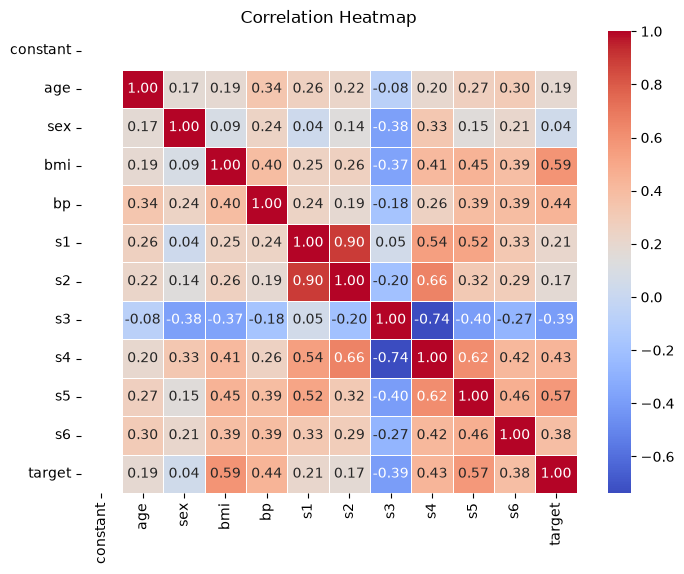

In [5]:
corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show() 

## 6. Train/test split
60% of the data trains the model, 40% is held out to evaluate it.

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.4, random_state=42
) 

## 7. Fit the model (OLS)
`OLS` = Ordinary Least Squares. `model.summary()` gives coefficients, standard
errors, p-values, R², and more — this is the core explainability report.

In [7]:
model = sm.OLS(y_train, x_train).fit()
print(model.summary()) 

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     26.14
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           7.41e-34
Time:                        15:11:33   Log-Likelihood:                -1434.5
No. Observations:                 265   AIC:                             2891.
Df Residuals:                     254   BIC:                             2930.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        148.9285      3.418     43.574      0.0

## 8. Predictions vs. actuals (spot check)

In [8]:
predictions = model.predict(x_test)
print("Predictions:", " ".join(f"{v:.0f}" for v in predictions[:10]))
print("Actuals:    ", " ".join(f"{v:.0f}" for v in y_test[:10])) 

Predictions: 137 181 131 277 120 92 262 182 81 113
Actuals:     219 70 202 230 111 84 242 272 94 96


## 9. Model performance
- **RMSE**: average prediction error, in the same units as the target.
- **R²**: proportion of variance in the target explained by the model (0 to 1).
- **Adjusted R²**: same as R², but penalizes adding features that don't help.

In [9]:
rms = np.sqrt(mse(y_test, predictions))
print("RMSE: {:.2f}".format(rms))
print("R2: {:.2f}".format(model.rsquared))
print("Adjusted R2: {:.2f}".format(model.rsquared_adj)) 

RMSE: 53.23
R2: 0.51
Adjusted R2: 0.49


## 10. Build the explainability summary table
`importance = coefficient / standard error` — this is mathematically the same
information as the t-statistic in the model summary above. A large coefficient
with a small standard error (high confidence) gets a high importance score.

In [10]:
std_errors = model.bse
conf_intervs = model.conf_int()

dfSummary = pd.DataFrame({
    'Variable': columns,
    'Coefficient': model.params,
    'Standard Error': std_errors,
    'coeff_lb': conf_intervs[:, 0],
    'coeff_ub': conf_intervs[:, 1]
})
dfSummary["importance"] = dfSummary["Coefficient"] / dfSummary["Standard Error"]
dfSummary.head(11) 

,Variable,Coefficient,Standard Error,coeff_lb,coeff_ub,importance
0,constant,148.928508,3.417863,142.197548,155.659469,43.573574
1,age,18.087998,80.182400,-139.819015,175.995010,0.225586
2,sex,-227.043449,79.870412,-384.336048,-69.750849,-2.842648
3,bmi,592.277235,89.602213,415.819338,768.735132,6.610074
4,bp,361.541232,84.602383,194.929738,528.152727,4.273417
5,s1,-655.907388,517.735348,-1675.508222,363.693446,-1.266878
6,s2,353.716364,418.184571,-469.834391,1177.267120,0.845838
7,s3,14.412655,262.325719,-502.197855,531.023164,0.054942
8,s4,142.873694,214.478926,-279.509851,565.257239,0.666143
9,s5,594.015429,226.071936,148.801218,1039.229640,2.627551


## 11. Sort by importance

In [11]:
dfSorted = dfSummary.sort_values(by="importance", ascending=False)
dfSorted.head(11) 

,Variable,Coefficient,Standard Error,coeff_lb,coeff_ub,importance
0,constant,148.928508,3.417863,142.197548,155.659469,43.573574
3,bmi,592.277235,89.602213,415.819338,768.735132,6.610074
4,bp,361.541232,84.602383,194.929738,528.152727,4.273417
9,s5,594.015429,226.071936,148.801218,1039.229640,2.627551
6,s2,353.716364,418.184571,-469.834391,1177.267120,0.845838
8,s4,142.873694,214.478926,-279.509851,565.257239,0.666143
10,s6,31.673180,89.063166,-143.723146,207.069506,0.355626
1,age,18.087998,80.182400,-139.819015,175.995010,0.225586
7,s3,14.412655,262.325719,-502.197855,531.023164,0.054942
5,s1,-655.907388,517.735348,-1675.508222,363.693446,-1.266878


## 12. Prepare data for the feature importance plot
We drop the intercept row and the least important row so the chart stays readable.

In [12]:
lineLabels = dfSorted['Variable'].values[1:-1]
lowerBounds = dfSorted['coeff_lb'].values[1:-1]
upperBounds = dfSorted['coeff_ub'].values[1:-1]
coefficients = dfSorted['Coefficient'].values[1:-1]
importances = dfSorted['importance'].values[1:-1]

minX = np.array(lowerBounds).min()
maxX = np.array(upperBounds).max()
xvalues = np.linspace(minX, maxX, 10, dtype='int')

maxY = int(np.array(importances).max() + 1)
minY = int(np.array(importances).min() - 1)
yvalues = np.linspace(minY, maxY, 10, dtype='int')

left, right, top, bottom = [], [], [], []
for imp, lb, ub, coef in zip(importances, lowerBounds, upperBounds, coefficients):
    left.append([lb, ub])
    right.append([imp, imp])
    top.append([coef, coef])
    bottom.append([imp - 0.02, imp + 0.02]) 

## 13. Plot feature importance
Each horizontal line = a feature's confidence interval. Its height on the y-axis =
importance. The red tick = the actual coefficient value. `bmi` should come out on top.

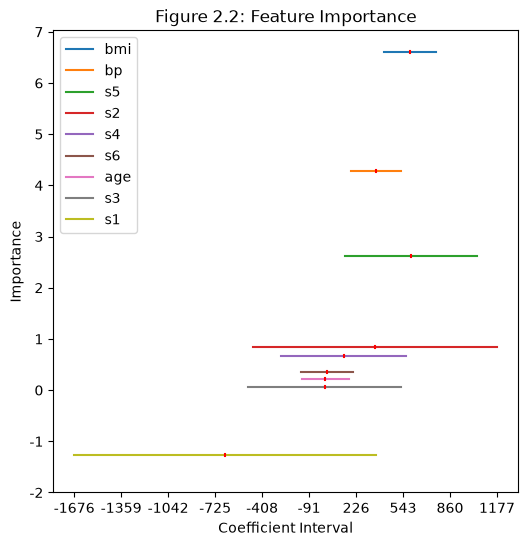

In [13]:
fig, ax = plt.subplots()
fig.set_figwidth(6)
fig.set_figheight(6)

for i in range(len(left)):
    ax.plot(left[i], right[i], linestyle='-', label=lineLabels[i])
    ax.plot(top[i], bottom[i], color='red')

ax.set_xticks(xvalues, xvalues)
ax.set_yticks(yvalues, yvalues)
ax.set_xlabel('Coefficient Interval')
ax.set_ylabel('Importance')
ax.set_title('Figure 2.2: Feature Importance')
ax.legend()
plt.show() 

## 14. Reading the results

- **R² = 0.51** — the model explains about half the variance in disease progression.
- **RMSE ≈ 53** — average prediction error, moderate relative to a target range of roughly 25-350.
- **Statistically significant predictors (p < 0.05)**: `sex`, `bmi`, `bp`, `s5` — check the
  `P>|t|` column in the model summary above; these are the only coefficients we can trust
  aren't actually zero.
- **Feature importance**: `bmi` and `s5` are the strongest positive drivers (large positive
  coefficient + low p-value). `sex` has a smaller but statistically real *negative* effect.
- Features like `age`, `s1`, `s3` have large or unstable coefficients but high p-values —
  meaning we can't be confident their true effect isn't zero, so we don't read much into them.